In [2]:
import pandas as pd

In [6]:
# Full dataset (2018–2025)
df_full = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/Police_Department_Stop_Data_2018 July to 2025 10.27.csv",
    low_memory=False
)

# Clean reference dataset (2018–2023)
df_clean = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/SFPD_stop_cleaned_data.csv",
    low_memory=False
)

In [7]:
clean_vars = df_clean.columns
len(clean_vars), list(clean_vars)

(46,
 ['doj_record_id',
  'person_number',
  'agency_ori',
  'stop_datetime',
  'duration_of_stop',
  'is_stop_response_to_call',
  'location',
  'district',
  'city',
  'perceived_race_ethnicity',
  'perceived_gender',
  'is_lgbt',
  'perceived_age',
  'perceived_age_group',
  'had_limited_or_no_english',
  'perceived_or_known_disability',
  'reason_for_stop',
  'traffic_violation_type',
  'traffic_viol_cjis_off_code',
  'traffic_viol_off_code',
  'traffic_viol_off_statute',
  'suspicion_cjis_off_code',
  'suspicion_off_code_txt',
  'suspicion_off_statute',
  'suspicion_sub_type',
  'actions_taken',
  'basis_for_search',
  'basis_for_property_seizure',
  'type_of_property_seized',
  'contraband_or_evidence',
  'results_of_stop',
  'longitude',
  'latitude',
  'supervisor_district',
  'analysis_neighborhoods',
  'perceived_race_ethnicity_code',
  'perceived_gender_code',
  'perceived_or_known_disability_code',
  'reason_for_stop_code',
  'actions_taken_code',
  'basis_for_search_code',

In [8]:
df_2018_2025_aligned = df_full.loc[:, df_full.columns.intersection(clean_vars)].copy()

In [9]:
import numpy as np

clean_cols = list(df_clean.columns)

# 1) Reindex to the clean column set:
#    - columns that exist in df_full will be kept
#    - columns missing in df_full will be created with NaN
df_2018_2025_aligned = df_full.reindex(columns=clean_cols)

print("Rows:", df_2018_2025_aligned.shape[0])
print("Columns:", df_2018_2025_aligned.shape[1])
print("Same column set:", list(df_2018_2025_aligned.columns) == list(df_clean.columns))
df_2018_2025_aligned.shape

Rows: 314832
Columns: 46
Same column set: True


(314832, 46)

In [10]:
df_2018_2025_aligned.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/StopData_2018_2025_aligned_to_clean.csv",
    index=False
)

In [11]:
# Variables to drop (non-essential for VoD + arrest analysis)
drop_cols = [
    # IDs / administrative
    "doj_record_id",
    "person_number",
    "agency_ori",

    # Search / seizure details
    "basis_for_property_seizure",
    "basis_for_property_seizure_code",
    "type_of_property_seized",
    "type_of_property_seized_code",
    "contraband_or_evidence",
    "contraband_or_evidence_code",

    # Suspicion details
    "suspicion_cjis_off_code",
    "suspicion_off_code_txt",
    "suspicion_off_statute",
    "suspicion_sub_type",
    "suspicion_sub_type_code",

    # Demographic / communication fields not used
    "is_lgbt",
    "perceived_age",
    "perceived_age_group",
    "had_limited_or_no_english",
    "perceived_or_known_disability",
    "perceived_or_known_disability_code"
]

df_2018_2025_aligned = df_2018_2025_aligned.drop(columns=drop_cols, errors="ignore")
df_2018_2025_aligned.shape

(314832, 26)

In [12]:
import pandas as pd

df_2018_2025_aligned["stop_datetime"] = pd.to_datetime(df_2018_2025_aligned["stop_datetime"], errors="coerce")
df_2018_2025_aligned = df_2018_2025_aligned.dropna(subset=["stop_datetime"]).copy()

df_2018_2025_aligned["stop_datetime"].head()
df_2018_2025_aligned.shape

(314832, 26)

In [13]:
# DGO 9.07 effective date
cutoff = pd.Timestamp("2024-07-17")

# 1 = post-policy (on/after 2024-07-17), 0 = pre-policy
df_2018_2025_aligned["post_DGO"] = (
    df_2018_2025_aligned["stop_datetime"] >= cutoff
).astype(int)

df_2018_2025_aligned["post_DGO"].value_counts()

post_DGO
0    275712
1     39120
Name: count, dtype: int64

In [14]:
df_2018_2025_aligned.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_working_df.csv",
    index=False
)

In [15]:
df = df_2018_2025_aligned

In [16]:
import pandas as pd

sun = pd.read_excel(
    "/Users/thisisjasmine/Desktop/ECO225/sf_sun_times_2018.7.1_2025.9.30.xlsx"
)

sun.head()

,date,sunrise,sunset
0,2018-07-01,05:51:00,20:35:00
1,2018-07-02,05:52:00,20:35:00
2,2018-07-03,05:52:00,20:35:00
3,2018-07-04,05:53:00,20:34:00
4,2018-07-05,05:53:00,20:34:00


In [17]:
sun["date"] = pd.to_datetime(sun["date"]).dt.date

In [18]:
df["stop_datetime"] = pd.to_datetime(df["stop_datetime"], errors="coerce")
df = df.dropna(subset=["stop_datetime"]).copy()

df["date"] = df["stop_datetime"].dt.date

In [19]:
df = df.merge(
    sun,
    on="date",
    how="left"
)

In [20]:
df[["stop_datetime", "sunrise", "sunset"]].head(10)
df["sunset"].isna().mean()

np.float64(0.0)

In [21]:
df[["date", "sunset"]].head(10)

,date,sunset
0,2024-09-25,19:00:00
1,2024-09-25,19:00:00
2,2024-09-25,19:00:00
3,2024-09-26,18:59:00
4,2024-09-26,18:59:00
5,2024-09-27,18:57:00
6,2024-09-27,18:57:00
7,2024-09-29,18:54:00
8,2024-09-30,18:53:00
9,2024-09-30,18:53:00


In [22]:
df["sunset_datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["sunset"].astype(str),
    errors="coerce"
)

In [23]:
df["after_sunset"] = (df["stop_datetime"] >= df["sunset_datetime"]).astype(int)

df["night"] = df["after_sunset"]

In [24]:
df.loc[df["night"] == 0, ["stop_datetime", "sunset_datetime"]].head()

,stop_datetime,sunset_datetime
0,2024-09-25 01:11:00,2024-09-25 19:00:00
1,2024-09-25 13:06:00,2024-09-25 19:00:00
2,2024-09-25 18:07:00,2024-09-25 19:00:00
3,2024-09-26 04:14:00,2024-09-26 18:59:00
4,2024-09-26 17:49:00,2024-09-26 18:59:00


In [25]:
df["sunrise_datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["sunrise"].astype(str),
    errors="coerce"
)

In [26]:
df["before_sunrise"] = (df["stop_datetime"] < df["sunrise_datetime"]).astype(int)

In [27]:
df["before_sunrise"].value_counts()

before_sunrise
0    280965
1     33867
Name: count, dtype: int64

In [28]:
df.loc[df["before_sunrise"] == 1, ["stop_datetime", "sunrise_datetime"]].head()

,stop_datetime,sunrise_datetime
0,2024-09-25 01:11:00,2024-09-25 07:00:00
3,2024-09-26 04:14:00,2024-09-26 07:01:00
10,2024-10-01 00:31:00,2024-10-01 07:06:00
28,2024-10-12 02:06:00,2024-10-12 07:16:00
38,2024-10-18 01:15:00,2024-10-18 07:21:00


In [29]:
df.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod.csv",
    index=False
)

In [30]:
df["low_visibility"] = ((df["after_sunset"] == 1) | (df["before_sunrise"] == 1)).astype(int)

In [31]:
df.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod1.csv",
    index=False
)

In [20]:
df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod2.csv",
    low_memory=False
)

In [21]:
df["perceived_race_ethnicity"] = df["perceived_race_ethnicity"].replace({
    "Black / African American": "Black/African American",
    "Hispanic/Latino(a)": "Hispanic/Latine(x)",
    "Hispanic / Latine(x)" : "Hispanic/Latine(x)"
})

In [22]:
df["perceived_race_ethnicity"].value_counts()

perceived_race_ethnicity
White                            106310
Black/African American            75810
Hispanic/Latine(x)                65444
Asian                             35446
Middle Eastern or South Asian     20493
Multi-racial                       6068
Pacific Islander                   3808
Other                              1008
Native American                     445
Name: count, dtype: int64

In [23]:
df.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod2.csv",
    index=False
)

In [24]:
table_counts = (
    df
    .pivot_table(
        index="perceived_race_ethnicity",
        columns=["post_DGO", "low_visibility"],
        values="stop_datetime",
        aggfunc="count",
        fill_value=0
    )
)

In [25]:
table_counts["change_rate_low_visibility"] = (
    table_counts[(1, 1)] - table_counts[(0, 1)]
) / table_counts[(0, 1)]

table_counts["change_rate_high_visibility"] = (
    table_counts[(1, 0)] - table_counts[(0, 0)]
) / table_counts[(0, 0)]

In [26]:
final_table = table_counts.reset_index()

final_table = final_table.rename(columns={
    (0, 0): "Pre-DGO, Daylight",
    (0, 1): "Pre-DGO, Low Visibility",
    (1, 0): "Post-DGO, Daylight",
    (1, 1): "Post-DGO, Low Visibility",
    "change_rate_low_visibility": "Change Rate (Low Visibility)",
    "change_rate_high_visibility": "Change Rate (Daylight)"
})

In [27]:
final_table

post_DGO             perceived_race_ethnicity      0            1        \
low_visibility                                     0      1     0     1   
0                                       Asian  21216   9167  3781  1282   
1                      Black/African American  41955  25778  5775  2302   
2                          Hispanic/Latine(x)  34520  21155  6686  3083   
3               Middle Eastern or South Asian  12213   5710  1766   804   
4                                Multi-racial   3883   2185     0     0   
5                             Native American    263    124    44    14   
6                                       Other    281    163   403   161   
7                            Pacific Islander   2145   1211   312   140   
8                                       White  64764  28979  9304  3263   

post_DGO       Change Rate (Low Visibility) Change Rate (Daylight)  
low_visibility                                                      
0                                 -0.860151              -0.821785  
1                                 -0.910699              -0.862353  
2                                 -0.854266              -0.806315  
3                                 -0.859194              -0.855400  
4                                 -1.000000              -1.000000  
5                                 -0.887097              -0.832700  
6                                 -0.012270               0.434164  
7                                 -0.884393              -0.854545  
8                                 -0.887401              -0.856340

In [28]:
# Make sure date is string
date_str = df["date"].astype(str)

df["sunrise_datetime"] = pd.to_datetime(
    date_str + " " + df["sunrise"].astype(str),
    errors="coerce"
)

df["sunset_datetime"] = pd.to_datetime(
    date_str + " " + df["sunset"].astype(str),
    errors="coerce"
)

In [29]:
buffer = pd.Timedelta(minutes=30)

df["after_sunset_30"] = df["stop_datetime"] >= (df["sunset_datetime"] + buffer)
df["before_sunrise_30"] = df["stop_datetime"] <= (df["sunrise_datetime"] - buffer)

df["low_visibility"] = (
    df["after_sunset_30"] | df["before_sunrise_30"]
).astype(int)


In [30]:
df["low_visibility"] = (
    df["after_sunset_30"] | df["before_sunrise_30"]
).astype(int)

In [32]:
df = df[
    df["after_sunset_30"] | 
    df["before_sunrise_30"] |
    (
        (df["stop_datetime"] > df["sunrise_datetime"] + buffer) &
        (df["stop_datetime"] < df["sunset_datetime"] - buffer)
    )
].copy()

In [33]:
df.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod3.csv",
    index=False
)

In [16]:
df["searched"] = df["basis_for_search"].notna().astype(int)

In [15]:
df["is_daylight"] = ((df["before_sunrise"] == 0) & (df["after_sunset"] == 0)).astype(int)

In [1]:
import pandas as pd
from IPython.display import display, HTML

df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/sfpd_with_sun_and_vod4.csv",
    low_memory=False
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

BLUE = "#1f77b4"
WHITE = "white"
EDGE = "black"

df["stop_datetime"] = pd.to_datetime(df["stop_datetime"],
                                     errors="coerce")
df = df.dropna(subset=["stop_datetime"]).copy()
df["month"] = df["stop_datetime"].dt.to_period("M").astype(str)

df["post_DGO"] = pd.to_numeric(df["post_DGO"], errors="coerce")
df["low_visibility"] = pd.to_numeric(df["low_visibility"],
                                     errors="coerce").fillna(0).astype(int)
df["daylight"] = 1 - df["low_visibility"]
df = df.dropna(subset=["post_DGO", "low_visibility"]).copy()
df["post_DGO"] = df["post_DGO"].astype(int)

df["searched"] = df["basis_for_search"].notna().astype(int)
df["perceived_race_ethnicity_code"] = pd.to_numeric(
    df["perceived_race_ethnicity_code"], errors="coerce"
)
race_map = {
    1: "Asian",
    2: "Black/African American",
    3: "Hispanic/Latino(a)",
    4: "Middle Eastern or South Asian",
    5: "Native American",
    6: "Pacific Islander",
    7: "White"
}
race_order = [
    "Asian",
    "Black/African American",
    "Hispanic/Latino(a)",
    "Middle Eastern or South Asian",
    "Native American",
    "Pacific Islander",
    "White"
]
df["race_label"] = df["perceived_race_ethnicity_code"].map(race_map)
df = df.dropna(subset=["race_label"]).copy()

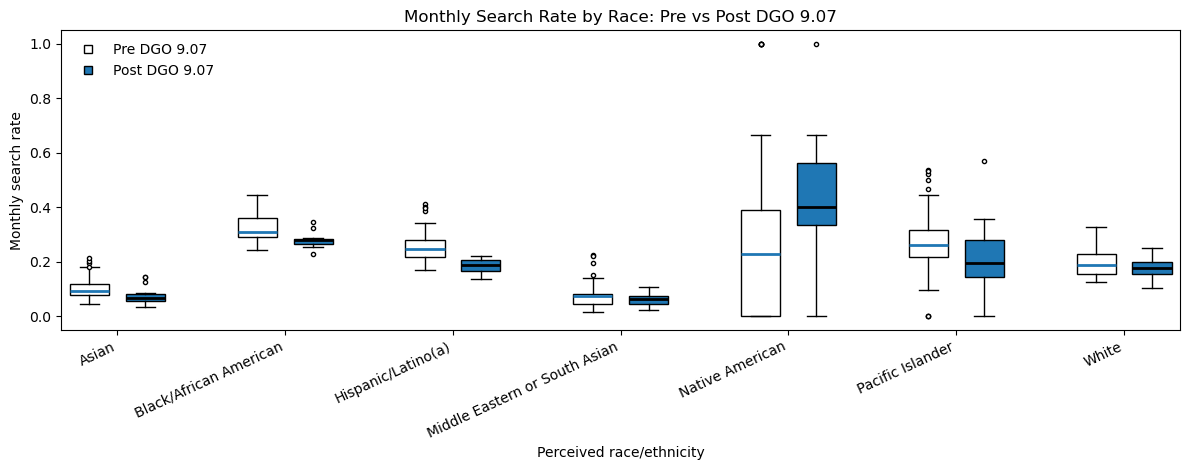

In [3]:
monthly_race = (
    df.groupby(["race_label", "post_DGO", "month"])["searched"]
      .mean()
      .reset_index(name="search_rate")
)
data_pre = [monthly_race[(monthly_race["race_label"] == r) &
    (monthly_race["post_DGO"] == 0)]["search_rate"].values
            for r in race_order]
data_post = [monthly_race[(monthly_race["race_label"] == r) &
    (monthly_race["post_DGO"] == 1)]["search_rate"].values
             for r in race_order]

fig1, ax = plt.subplots(figsize=(12, 4.8))

positions_pre = np.arange(len(race_order)) * 3 + 1
positions_post = positions_pre + 1

bp1 = ax.boxplot(
    data_pre,
    positions=positions_pre,
    widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor=WHITE, edgecolor=EDGE),
    whiskerprops=dict(color=EDGE),
    capprops=dict(color=EDGE),
    medianprops=dict(color=BLUE, linewidth=2),
    flierprops=dict(marker="o", markersize=3, markerfacecolor=WHITE,
                    markeredgecolor=EDGE),
)

bp2 = ax.boxplot(
    data_post,
    positions=positions_post,
    widths=0.7,
    patch_artist=True,
    boxprops=dict(facecolor=BLUE, edgecolor=EDGE),
    whiskerprops=dict(color=EDGE),
    capprops=dict(color=EDGE),
    medianprops=dict(color=EDGE, linewidth=2),
    flierprops=dict(marker="o", markersize=3, markerfacecolor=WHITE,
                    markeredgecolor=EDGE),
)

ax.set_title("Monthly Search Rate by Race: Pre vs Post DGO 9.07")
ax.set_ylabel("Monthly search rate")
ax.set_xlabel("Perceived race/ethnicity")

ax.set_xticks(positions_pre + 0.5)
ax.set_xticklabels(race_order, rotation=25, ha="right")

ax.plot([], [], color=EDGE, marker="s", linestyle="None",
        markerfacecolor=WHITE, label="Pre DGO 9.07")
ax.plot([], [], color=EDGE, marker="s", linestyle="None",
        markerfacecolor=BLUE,  label="Post DGO 9.07")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

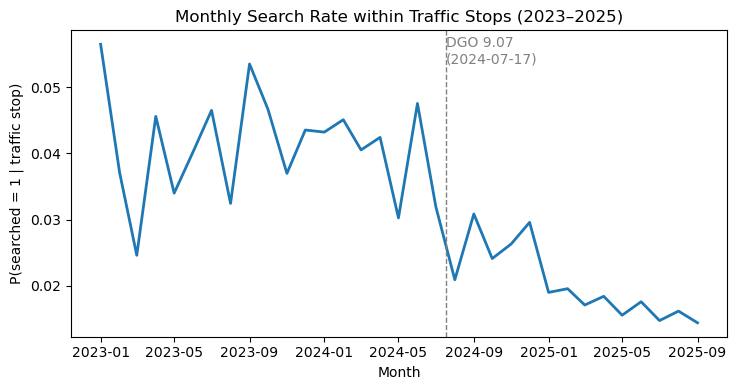

In [4]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
d = df.dropna(subset=["date"]).copy()

d["year"] = d["date"].dt.year
d["month"] = d["date"].dt.to_period("M").dt.to_timestamp()

d["searched"] = pd.to_numeric(d["searched"], errors="coerce")
d["reason_for_stop_code"] = pd.to_numeric(d["reason_for_stop_code"],
                                          errors="coerce")

d = d[(d["year"] >= 2023) & (d["year"] <= 2025)].copy()
d["traffic_stop"] = (d["reason_for_stop_code"] == 1).astype(int)

monthly_search_rate = (
    d[d["traffic_stop"] == 1]
    .dropna(subset=["searched"])
    .groupby("month")["searched"]
    .mean()
)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(monthly_search_rate.index, monthly_search_rate.values,
        color=BLUE, linewidth=2)

policy_date = pd.Timestamp("2024-07-17")
ax.axvline(policy_date, linestyle="--", color="gray", linewidth=1)
ax.text(
    policy_date, 0.98,
    "DGO 9.07\n(2024-07-17)",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top", color="gray"
)

ax.set_title("Monthly Search Rate within Traffic Stops (2023–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("P(searched = 1 | traffic stop)")

plt.tight_layout()
plt.show()

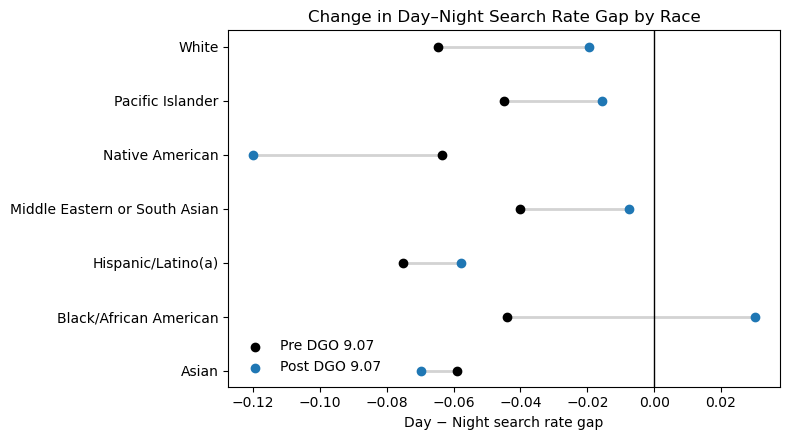

In [5]:
gap_plot = (
    df.groupby(["race_label", "post_DGO", "daylight"])["searched"]
      .mean()
      .unstack("daylight")
      .reindex(columns=[0, 1])              
      .rename(columns={0: "Night", 1: "Day"})
)

gap_plot["gap"] = gap_plot["Day"] - gap_plot["Night"]

gap_plot = (
    gap_plot["gap"]
    .reset_index()
    .pivot(index="race_label", columns="post_DGO", values="gap")
    .rename(columns={0: "Pre", 1: "Post"})
    .reindex(race_order)                   
)

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(gap_plot.index))

ax.hlines(y=y, xmin=gap_plot["Pre"], xmax=gap_plot["Post"],
          color="lightgray", linewidth=2)
ax.scatter(gap_plot["Pre"], y, color="black", label="Pre DGO 9.07",
           zorder=3)
ax.scatter(gap_plot["Post"], y, color=BLUE,  label="Post DGO 9.07",
           zorder=3)

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(gap_plot.index)
ax.set_title("Change in Day–Night Search Rate Gap by Race")
ax.set_xlabel("Day − Night search rate gap")
ax.legend(frameon=False, loc="lower left")

plt.tight_layout()
plt.show()

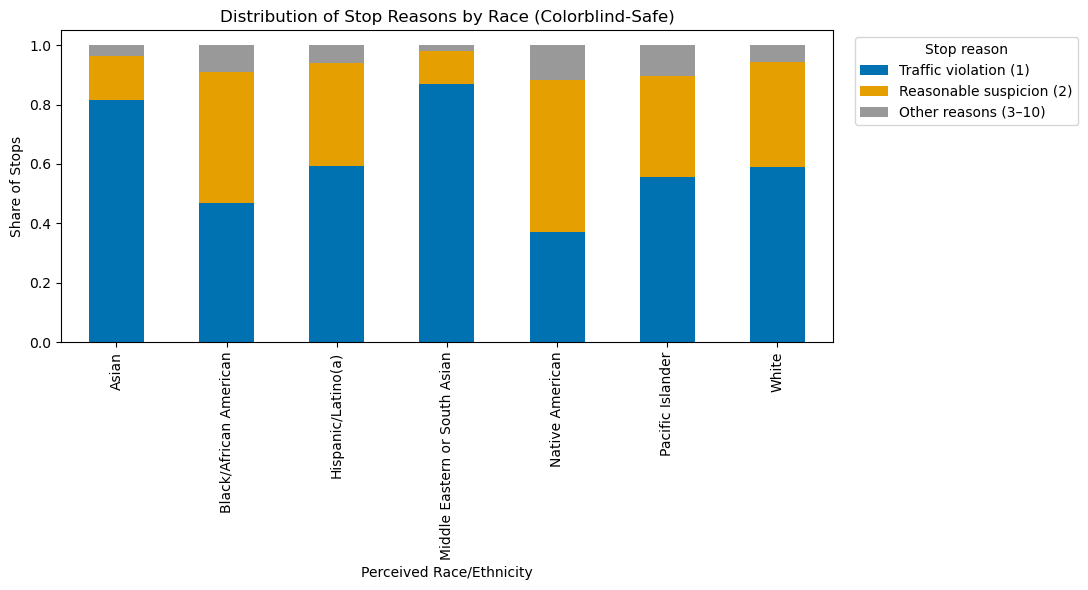

In [6]:
df["reason_for_stop_code"] = pd.to_numeric(df["reason_for_stop_code"],
                                           errors="coerce")

df["reason_group"] = np.select(
    [
        df["reason_for_stop_code"] == 1,
        df["reason_for_stop_code"] == 2
    ],
    [
        "Traffic violation (1)",
        "Reasonable suspicion (2)"
    ],
    default="Other reasons (3–10)"
)

plot_df = df.dropna(subset=["race_label", "reason_group"]).copy()

tab = pd.crosstab(plot_df["race_label"], plot_df["reason_group"], normalize="index")

if "race_order" in globals():
    tab = tab.reindex(race_order)

col_order = ["Traffic violation (1)", "Reasonable suspicion (2)",
             "Other reasons (3–10)"]
tab = tab.reindex(columns=col_order).fillna(0)

colors = [
    "#0072B2",  # Blue
    "#E69F00",  # Orange
    "#999999"   # Grey
]

ax = tab.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=colors
)

plt.xlabel("Perceived Race/Ethnicity")
plt.ylabel("Share of Stops")
plt.title("Distribution of Stop Reasons by Race (Colorblind-Safe)")
plt.legend(
    title="Stop reason",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()